<a href="https://colab.research.google.com/github/David2204269/RAHCE/blob/Pytorch_Entrenamiento/PyTorchVideo_EntrenamientoV4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
try:
    import torch
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "torch", "torchvision"])
    import torch

import sys

if torch.__version__ == '1.6.0+cu101' and sys.platform.startswith('linux'):
    import subprocess
    subprocess.run(["pip", "install", "pytorchvideo"])
else:
    need_pytorchvideo = False
    try:
        import pytorchvideo
    except ModuleNotFoundError:
        need_pytorchvideo = True
    if need_pytorchvideo:
        import subprocess
        subprocess.run(["pip", "install", "git+https://github.com/facebookresearch/pytorchvideo.git"])

import subprocess
subprocess.run(["pip", "install", "opencv-python", "av"])

CompletedProcess(args=['pip', 'install', 'opencv-python', 'av'], returncode=0)

In [ ]:
import os
import gc
import cv2
import torch
import numpy as np

import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

In [ ]:
ZIP_PATH = "/content/drive/MyDrive/Trabajo de grado/HMDB51.zip"
DEST_PATH = "/content/hmdb51_frames"

import subprocess
subprocess.run(["mkdir", "-p", DEST_PATH])
subprocess.run(["cp", ZIP_PATH, "/content/"])
subprocess.run(["unzip", "-q", "/content/HMDB51.zip", "-d", DEST_PATH])
subprocess.run(["cp", "-r", "/content/drive/MyDrive/Trabajo de grado/test_train_splits", "/content/"])

CompletedProcess(args=['cp', '-r', '/content/drive/MyDrive/Trabajo de grado/test_train_splits', '/content/'], returncode=0)

In [ ]:
FRAMES_PER_CLIP    = 16
STEP_BETWEEN_CLIPS = 16
IMG_SIZE           = 224
BATCH_SIZE         = 24
NUM_WORKERS        = 2
NUM_EPOCHS         = 20
VAL_SPLIT          = 0.2
LR                 = 5e-5
HEAD_DROPOUT       = 0.5
WEIGHT_DECAY       = 0.1
LABEL_SMOOTHING    = 0.1

NORM_MEAN = torch.tensor([0.45, 0.45, 0.45]).view(3, 1, 1, 1)
NORM_STD  = torch.tensor([0.225, 0.225, 0.225]).view(3, 1, 1, 1)

# Opciones disponibles: "slow_r50" | "x3d_s" | "x3d_m"
MODEL_NAME = "x3d_s"

In [ ]:
from torch.utils.data import Subset
import random

def split_dataset_by_video(dataset, val_split=0.2, seed=42):
    """
    Divide un dataset en train/val por video_id, no por clip.
    """
    video_to_indices = {}

    for idx, (_, _, _, video_id) in enumerate(dataset.clips):
        if video_id not in video_to_indices:
            video_to_indices[video_id] = []
        video_to_indices[video_id].append(idx)

    video_ids = list(video_to_indices.keys())
    random.seed(seed)
    random.shuffle(video_ids)

    n_val_videos = max(1, int(len(video_ids) * val_split))
    val_video_ids = set(video_ids[:n_val_videos])
    train_video_ids = set(video_ids[n_val_videos:])

    train_indices = []
    val_indices   = []

    for vid in train_video_ids:
        train_indices.extend(video_to_indices[vid])

    for vid in val_video_ids:
        val_indices.extend(video_to_indices[vid])

    train_dataset = Subset(dataset, train_indices)
    val_dataset   = Subset(dataset, val_indices)

    print(f"Videos train: {len(train_video_ids)} | Videos val: {len(val_video_ids)}")
    print(f"Clips train: {len(train_indices)} | Clips val: {len(val_indices)}")

    return train_dataset, val_dataset

In [ ]:
def transform_clip(frames, train=True):
    """
    Convierte un stack numpy (T, H, W, C) en tensor (C, T, H, W) normalizado.
    """
    frames = torch.tensor(frames).float() / 255.0   # → [T, H, W, C], rango [0,1]
    frames = frames.permute(0, 3, 1, 2)             # → [T, C, H, W]

    # Resize espacial
    frames = F.interpolate(
        frames,
        size=(IMG_SIZE, IMG_SIZE),
        mode="bilinear",
        align_corners=False
    )                                                # → [T, C, H, W]

    frames = frames.permute(1, 0, 2, 3)             # → [C, T, H, W]

    # ── Normalización con media y std de Kinetics ────────────────────────────
    frames = (frames - NORM_MEAN) / NORM_STD

    # SIN data augmentation

    return frames

In [ ]:
class HMDB51Frames(Dataset):

    def __init__(self, root, annotation_path, fold=1, train=True):
        self.root            = root
        self.annotation_path = annotation_path
        self.fold            = fold
        self.train           = train
        self.frames_per_clip = FRAMES_PER_CLIP
        self.step            = STEP_BETWEEN_CLIPS

        self.classes      = sorted(os.listdir(root))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        self.clips = []
        video_id   = 0

        valid_videos = 0
        padded_videos = 0

        for cls in self.classes:
            split_file = os.path.join(
                annotation_path,
                f"{cls}_test_split{fold}.txt"
            )

            if not os.path.exists(split_file):
                continue

            with open(split_file) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 2:
                        continue

                    video_name, split_id = parts[0], int(parts[1])

                    if train and split_id != 1:
                        continue
                    if not train and split_id != 2:
                        continue

                    video_name   = video_name.replace(".avi", "")
                    video_folder = os.path.join(root, cls, video_name)

                    if not os.path.exists(video_folder):
                        continue

                    frame_files = sorted(os.listdir(video_folder))
                    n_frames    = len(frame_files)
                    label       = self.class_to_idx[cls]

                    if n_frames == 0:
                        continue

                    added = 0

                    # Si el video es corto, igual genera 1 clip y luego
                    # __getitem__ hace el padding temporal.
                    if n_frames < self.frames_per_clip:
                        self.clips.append((video_folder, 0, label, video_id))
                        padded_videos += 1
                        added += 1
                    else:
                        for start in range(0, n_frames - self.frames_per_clip + 1, self.step):
                            self.clips.append((video_folder, start, label, video_id))
                            added += 1

                    if added > 0:
                        valid_videos += 1
                        video_id += 1

        print(
            f"[{'Train' if train else 'Test'} fold={fold}] "
            f"{len(self.clips)} clips · {valid_videos} videos útiles · "
            f"{padded_videos} videos con padding · {len(self.classes)} clases"
        )

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        video_folder, start, label, video_id = self.clips[idx]

        frame_files = sorted(os.listdir(video_folder))
        n_frames = len(frame_files)

        frames = []

        for i in range(start, start + self.frames_per_clip):
            if i < n_frames:
                frame_path = os.path.join(video_folder, frame_files[i])
                img = cv2.imread(frame_path)

                if img is None:
                    if frames:
                        img = frames[-1]
                    else:
                        img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
                else:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            else:
                # Padding temporal: repetir el último frame válido
                if frames:
                    img = frames[-1]
                else:
                    img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

            frames.append(img)

        frames = np.stack(frames)                           # [T, H, W, C]
        clip   = transform_clip(frames, train=self.train)  # [C, T, H, W]

        return clip, label, video_id

In [ ]:
class PrefetchLoader:

    def __init__(self, loader, device):
        self.loader = loader
        self.device = device

    def __iter__(self):
        for videos, labels, video_ids in self.loader:
            videos = videos.to(self.device, non_blocking=True)
            labels = labels.to(self.device, non_blocking=True)
            yield videos, labels, video_ids

    def __len__(self):
        return len(self.loader)

In [ ]:
from pytorchvideo.models.hub import slow_r50, x3d_s, x3d_m

def create_model(model_name="x3d_s", num_classes=51, head_dropout=0.5):
    """
    Crea el modelo seleccionado con pesos preentrenados en Kinetics-400
    y reemplaza la capa de clasificación final con Dropout + Linear.
    """

    if model_name == "slow_r50":
        model = slow_r50(pretrained=True)
        in_features = 2048
        model.blocks[-1].proj = nn.Sequential(
            nn.Dropout(p=head_dropout),
            nn.Linear(in_features, num_classes)
        )

    elif model_name == "x3d_s":
        model = x3d_s(pretrained=True)
        in_features = 2048
        model.blocks[-1].proj = nn.Sequential(
            nn.Dropout(p=head_dropout),
            nn.Linear(in_features, num_classes)
        )

    elif model_name == "x3d_m":
        model = x3d_m(pretrained=True)
        in_features = 2048
        model.blocks[-1].proj = nn.Sequential(
            nn.Dropout(p=head_dropout),
            nn.Linear(in_features, num_classes)
        )

    else:
        raise ValueError(f"Modelo desconocido: {model_name}")

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(
        f"Modelo: {model_name} | Params: {total_params:,} | "
        f"Entrenables: {trainable_params:,} | Dropout: {head_dropout}"
    )

    return model

In [ ]:
def train_one_epoch(model, loader, optimizer, scaler, use_amp, label_smoothing=0.1):
    model.train()

    total_loss = 0.0
    correct    = 0
    total      = 0

    pbar = tqdm(loader, desc="Train", leave=False)

    for videos, labels, _ in pbar:
        optimizer.zero_grad()

        with autocast(device_type="cuda", enabled=use_amp):
            outputs = model(videos)
            loss = F.cross_entropy(
                outputs,
                labels,
                label_smoothing=label_smoothing
            )

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{correct / max(total, 1):.4f}"
        )

    return total_loss / len(loader), correct / max(total, 1)

In [ ]:
def evaluate(model, loader, use_amp):
    model.eval()

    video_logits = {}
    video_labels = {}
    total_loss   = 0
    total_clips  = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="Eval", leave=False)

        for videos, labels, video_ids in pbar:
            with autocast(device_type="cuda", enabled=use_amp):
                outputs = model(videos)
                loss    = F.cross_entropy(outputs, labels)

            total_loss  += loss.item()
            total_clips += 1

            for logit, label, vid in zip(outputs, labels, video_ids):
                vid = int(vid)
                if vid not in video_logits:
                    video_logits[vid] = []
                    video_labels[vid] = label.item()
                video_logits[vid].append(logit.cpu())

    correct = 0
    for vid in video_logits:
        avg_logit = torch.stack(video_logits[vid]).mean(0)
        if avg_logit.argmax().item() == video_labels[vid]:
            correct += 1

    return total_loss / max(total_clips, 1), correct / max(len(video_logits), 1)

In [ ]:
# === CONFIGURACIÓN GLOBAL ===

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = torch.cuda.is_available()

print(f"Device: {device}")
print(f"AMP enabled: {use_amp}")

Device: cuda
AMP enabled: True


In [ ]:
import os
import gc
import random
import matplotlib.pyplot as plt
from torch.utils.data import Subset
from torch.amp import autocast, GradScaler

split_accuracies = []
split_results    = {}

splits_to_use = [1]   # luego vuelves a [1, 2, 3]
use_amp = torch.cuda.is_available()

for fold in splits_to_use:
    print(f"\n{'='*50}")
    print(f" Split {fold}/{len(splits_to_use)}")
    print(f"{'='*50}")

    # ── Datasets ────────────────────────────────────────────────────────────
    full_train_dataset = HMDB51Frames(
        root="/content/hmdb51_frames",
        annotation_path="/content/test_train_splits",
        fold=fold,
        train=True
    )

    test_dataset = HMDB51Frames(
        root="/content/hmdb51_frames",
        annotation_path="/content/test_train_splits",
        fold=fold,
        train=False
    )

    # ── División train / val POR VIDEO ─────────────────────────────────────
    train_dataset, val_dataset = split_dataset_by_video(
        full_train_dataset,
        val_split=VAL_SPLIT,
        seed=42
    )

    # ── DataLoaders ─────────────────────────────────────────────────────────
    train_loader = PrefetchLoader(
        DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=True
        ),
        device
    )

    val_loader = PrefetchLoader(
        DataLoader(
            val_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True
        ),
        device
    )

    test_loader = PrefetchLoader(
        DataLoader(
            test_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True
        ),
        device
    )

    # ── Modelo ──────────────────────────────────────────────────────────────
    model = create_model(
        MODEL_NAME,
        num_classes=51,
        head_dropout=HEAD_DROPOUT
    ).to(device)

    # ── Optimizador ─────────────────────────────────────────────────────────
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scaler = GradScaler(enabled=use_amp)

    # ── Checkpoint / EarlyStopping / ReduceLROnPlateau ─────────────────────
    best_ckpt_path  = f"/content/best_model_split{fold}.pth"
    best_val_loss   = float("inf")

    es_patience     = 4
    es_counter      = 0

    rlrop_patience  = 1
    rlrop_factor    = 0.5
    rlrop_min_lr    = 1e-6
    rlrop_counter   = 0
    rlrop_best_loss = float("inf")

    # ── Historial ───────────────────────────────────────────────────────────
    train_losses, train_accs = [], []
    val_losses,   val_accs   = [], []

    for epoch in range(NUM_EPOCHS):

        # ── Train ─────────────────────────────────────────────────────────
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scaler,
            use_amp,
            label_smoothing=LABEL_SMOOTHING
        )

        # ── Validation ────────────────────────────────────────────────────
        val_loss, val_acc = evaluate(model, val_loader, use_amp)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
            f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
            f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} | "
            f"LR {current_lr:.2e}"
        )

        improved = val_loss < best_val_loss

        # ── ModelCheckpoint ───────────────────────────────────────────────
        if improved:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_ckpt_path)
            print(f"  [ModelCheckpoint] Mejor val_loss={best_val_loss:.4f} → guardado en {best_ckpt_path}")

        # ── ReduceLROnPlateau manual ──────────────────────────────────────
        if val_loss < rlrop_best_loss:
            rlrop_best_loss = val_loss
            rlrop_counter   = 0
        else:
            rlrop_counter += 1
            if rlrop_counter >= rlrop_patience:
                new_lr = max(current_lr * rlrop_factor, rlrop_min_lr)
                for pg in optimizer.param_groups:
                    pg["lr"] = new_lr
                rlrop_counter = 0
                print(f"  [ReduceLROnPlateau] LR reducido a {new_lr:.2e}")

        # ── EarlyStopping ─────────────────────────────────────────────────
        if improved:
            es_counter = 0
        else:
            es_counter += 1
            if es_counter >= es_patience:
                print(f"  [EarlyStopping] Sin mejora en {es_patience} épocas. Deteniendo.")
                break

    # ── Cargar el mejor checkpoint ─────────────────────────────────────────
    model.load_state_dict(torch.load(best_ckpt_path, map_location=device))

    # ── Test final ─────────────────────────────────────────────────────────
    test_loss, test_acc = evaluate(model, test_loader, use_amp)
    print(f"  [Test Final] Loss {test_loss:.4f} | Acc {test_acc:.4f}")

    split_accuracies.append(test_acc)
    split_results[fold] = {
        "train_loss": train_losses,
        "train_acc": train_accs,
        "val_loss": val_losses,
        "val_acc": val_accs,
        "test_loss": test_loss,
        "test_acc": test_acc
    }

    del model, optimizer, scaler
    gc.collect()
    torch.cuda.empty_cache()


 Split 1/1
[Train fold=1] 4282 clips · 3570 videos útiles · 1225 videos con padding · 51 clases
[Test fold=1] 1821 clips · 1530 videos útiles · 546 videos con padding · 51 clases
Videos train: 2856 | Videos val: 714
Clips train: 3393 | Clips val: 889
Modelo: x3d_s | Params: 3,079,173 | Entrenables: 3,079,173 | Dropout: 0.5


Train:   0%|          | 0/142 [00:00<?, ?it/s]

Eval:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 01/20 | Train Loss 2.9975 Acc 0.3823 | Val Loss 1.5685 Acc 0.6345 | LR 5.00e-05
  [ModelCheckpoint] Mejor val_loss=1.5685 → guardado en /content/best_model_split1.pth


Train:   0%|          | 0/142 [00:00<?, ?it/s]

...

Train:   0%|          | 0/142 [00:00<?, ?it/s]

Eval:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 11/20 | Train Loss 0.7973 Acc 0.9994 | Val Loss 0.7975 Acc 0.8067 | LR 6.25e-06
  [ReduceLROnPlateau] LR reducido a 3.13e-06
  [EarlyStopping] Sin mejora en 4 épocas. Deteniendo.


Eval:   0%|          | 0/76 [00:00<?, ?it/s]

  [Test Final] Loss 1.0874 | Acc 0.7131



  RESULTADO FINAL — Modelo: x3d_s
  Split 1: 0.7131 (71.3%)
  Promedio 3 splits: 0.7131 (71.3%)


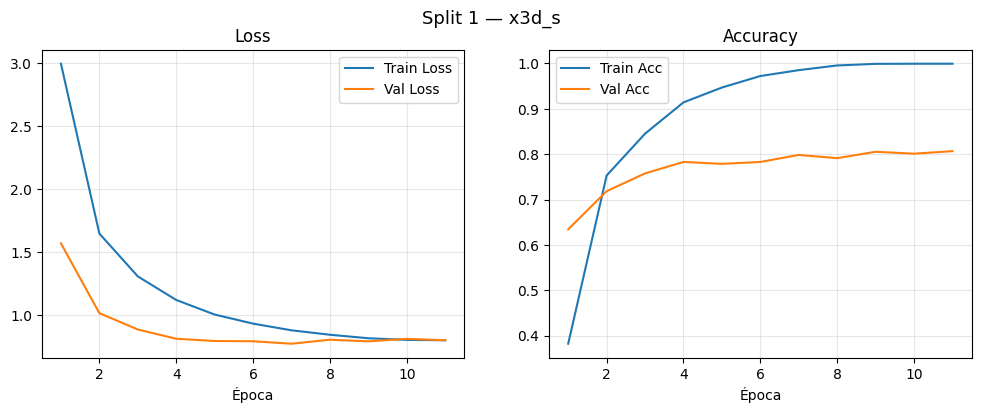

In [ ]:
final_acc = sum(split_accuracies) / len(split_accuracies)

print("\n" + "="*50)
print(f"  RESULTADO FINAL — Modelo: {MODEL_NAME}")
print("="*50)
for fold, acc in zip(splits_to_use, split_accuracies):
    print(f"  Split {fold}: {acc:.4f} ({acc*100:.1f}%)")
print(f"  Promedio 3 splits: {final_acc:.4f} ({final_acc*100:.1f}%)")
print("="*50)

for fold in split_results:
    data   = split_results[fold]
    epochs = range(1, len(data["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Split {fold} — {MODEL_NAME}", fontsize=13)

    axes[0].plot(epochs, data["train_loss"], label="Train Loss")
    axes[0].plot(epochs, data["val_loss"],   label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Época")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, data["train_acc"], label="Train Acc")
    axes[1].plot(epochs, data["val_acc"],   label="Val Acc")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Época")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.show()